# Feature & Label Engineering                                                                                                                
                                                                                                                                                
## Order of operations                                                                                                                                
1. Label engineering — map nutriscore_grade (A–E) to Healthy / Moderate / Avoid
2. Data cleaning — drop rows with bad/missing labels, impossible nutrient values                                                                      
3. Feature engineering — log transforms, nutrient ratios, normalization, category encoding
                                                                                                                                                
Labels come before features because label design influences which features matter,                                                                    
and we need clean labeled data before checking class balance or feature-target correlations.  

# Label Engineering

Mapping:
I would map the nutriscore_grade (A–E) to Healthy / Moderate / Avoid as:
- A, B → Healthy — good nutritional quality                                                                                                           
- C → Moderate — acceptable but not great                                                                                                             
- D, E → Avoid — poor nutritional quality  
I would be conservative, calling out D as unhealthy for the users rather than moderate, to warn someone away from a D food than to call it "moderate."

In [50]:
import pandas as pd                     
                                                                                                                                                    
df = pd.read_csv("../data/processed/openfoodfacts_us_clean.csv", low_memory=False)                                                                    
df.shape    

(531466, 13)

In [51]:
df['health_label']=df['nutriscore_grade'].map({'a':'Healthy','b':'Healthy','c':'Moderate', 'd':'Unhealthy','e':'Unhealthy'})
df['health_label'].value_counts()

health_label
Unhealthy    189826
Healthy       83858
Moderate      60300
Name: count, dtype: int64

In [52]:
df['health_label'].isnull().sum()

np.int64(197482)

There are 197k rows where health_label is null — those are all the unknown, not-applicable, and missing grade rows that map() couldn't match.
Lets drop them.


In [53]:
df = df.dropna(subset=['health_label'])

df.shape

(333984, 14)

In [54]:
#Data Cleaning, dropping rows with physically impossible values in the nutrient columns

import numpy as np                                                                                                                                    
                                                                                                                                                    
nutrient_cols = ['fat_100g', 'saturated-fat_100g', 'carbohydrates_100g',                                                                              
                'sugars_100g', 'fiber_100g', 'proteins_100g', 'sodium_100g']

for col in nutrient_cols:
    df[col] = np.where((df[col] < 0) | (df[col] > 100), np.nan, df[col])

In [55]:
df['energy-kcal_100g'] = np.where((df['energy-kcal_100g'] < 0) | (df['energy-kcal_100g'] < 900), np.nan, df['energy-kcal_100g'])

In [56]:
df.isnull().sum()

product_name             225
categories               992
countries                  0
nutriscore_score           0
nutriscore_grade           0
energy-kcal_100g      319033
fat_100g                7470
saturated-fat_100g     29784
carbohydrates_100g     15234
sugars_100g            16195
fiber_100g             45831
proteins_100g           3002
sodium_100g             1774
health_label               0
dtype: int64

In [57]:
 df['energy-kcal_100g'].describe()
 

count    14951.000000
mean      1915.712745
std       1374.864251
min        900.000000
25%       1170.000000
50%       1450.000000
75%       2040.000000
max      26400.000000
Name: energy-kcal_100g, dtype: float64

## Observation for the energy-kcal_100g feature

The mean is 1,915 kcal — that's way above 900. This tells us the column is likely in kJ, not kcal, for most rows, despite being named
energy-kcal_100g. 900 kJ per 100g is actually reasonable — 900 kcal per 100g is only pure fat. So our cap was wrong for the unit. Looking at the min value: 900. That means every surviving value is exactly at our cutoff boundary. We've essentially wiped out the entire column.

Solution:
We can drop energy-kcal_100g from your feature list. Calories are already partially captured by fat, carbohydrates, and proteins (the
macros that make up calories). It's redundant and clearly unreliable in this dataset.

In [58]:
df.drop(columns=['energy-kcal_100g'], inplace=True)

In [59]:
df.columns

Index(['product_name', 'categories', 'countries', 'nutriscore_score',
       'nutriscore_grade', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g',
       'sodium_100g', 'health_label'],
      dtype='object')

  ## Key Decisions & Interview Prep                                                                                                                                                                                          
                                                                                                                                                                                                                             
  ### Label mapping (A-E → Healthy/Moderate/Avoid)
  D goes in Avoid, not Moderate — the app's purpose is to help users make better choices,                                                                                                                                    
  and a D-rated food has meaningfully poor nutrition. Conservative labeling is better for users.                                                                                                                             
                                                                                                                                                                                                                             
  ### Class imbalance → class weights                                                                                                                                                                                        
  Used class weights over resampling to avoid data duplication and retain the full training set.                                                                                                                             
  Resampling either duplicates minority rows (overfitting risk) or discards majority rows (wastes data).                                                                                                                     
  Both sklearn and XGBoost support class_weight='balanced' natively.                                                                                                                                                         
                                                                                                                                                                                                                             
  ### Impossible values → set to NaN, not drop row                                                                                                                                                                           
  Preserves valid nutrient data in other columns. Fits naturally into existing missing value strategy.                                                                                                                       
                                                                                                                                                                                                                             
  ### energy-kcal_100g dropped                                                                                                                                                                                               
  Column appeared to be in kJ not kcal despite the name — cap of 900 wiped out 95% of values.                                                                                                                                
  Calories are already captured by fat, carbs, and proteins (the macros that compose calories).                                                                                                                              
                                          
  ### Log transform → log1p                                                                                                                                                                                                  
  Used log1p instead of log because nutrient values legitimately include zeros.                                                                                                                                              
  log1p maps zero to zero and avoids undefined values. Compresses right-skewed distributions.
  log(0 + 1) = log(1) = 0 — so a zero value stays zero after the transform. And small values stay small, large values get compressed. The relative ordering is preserved.                                           
  This is called log1p transform and numpy has a built-in for it: np.log1p()

In [60]:
columns = ['fat_100g', 'saturated-fat_100g','carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g','sodium_100g']                                                                                                                                                                                                    
for col in columns:                                                                                                                                                                                                       
  df[f"log_{col}"] = np.log1p(df[col])  

df.columns.to_list()

['product_name',
 'categories',
 'countries',
 'nutriscore_score',
 'nutriscore_grade',
 'fat_100g',
 'saturated-fat_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'fiber_100g',
 'proteins_100g',
 'sodium_100g',
 'health_label',
 'log_fat_100g',
 'log_saturated-fat_100g',
 'log_carbohydrates_100g',
 'log_sugars_100g',
 'log_fiber_100g',
 'log_proteins_100g',
 'log_sodium_100g']

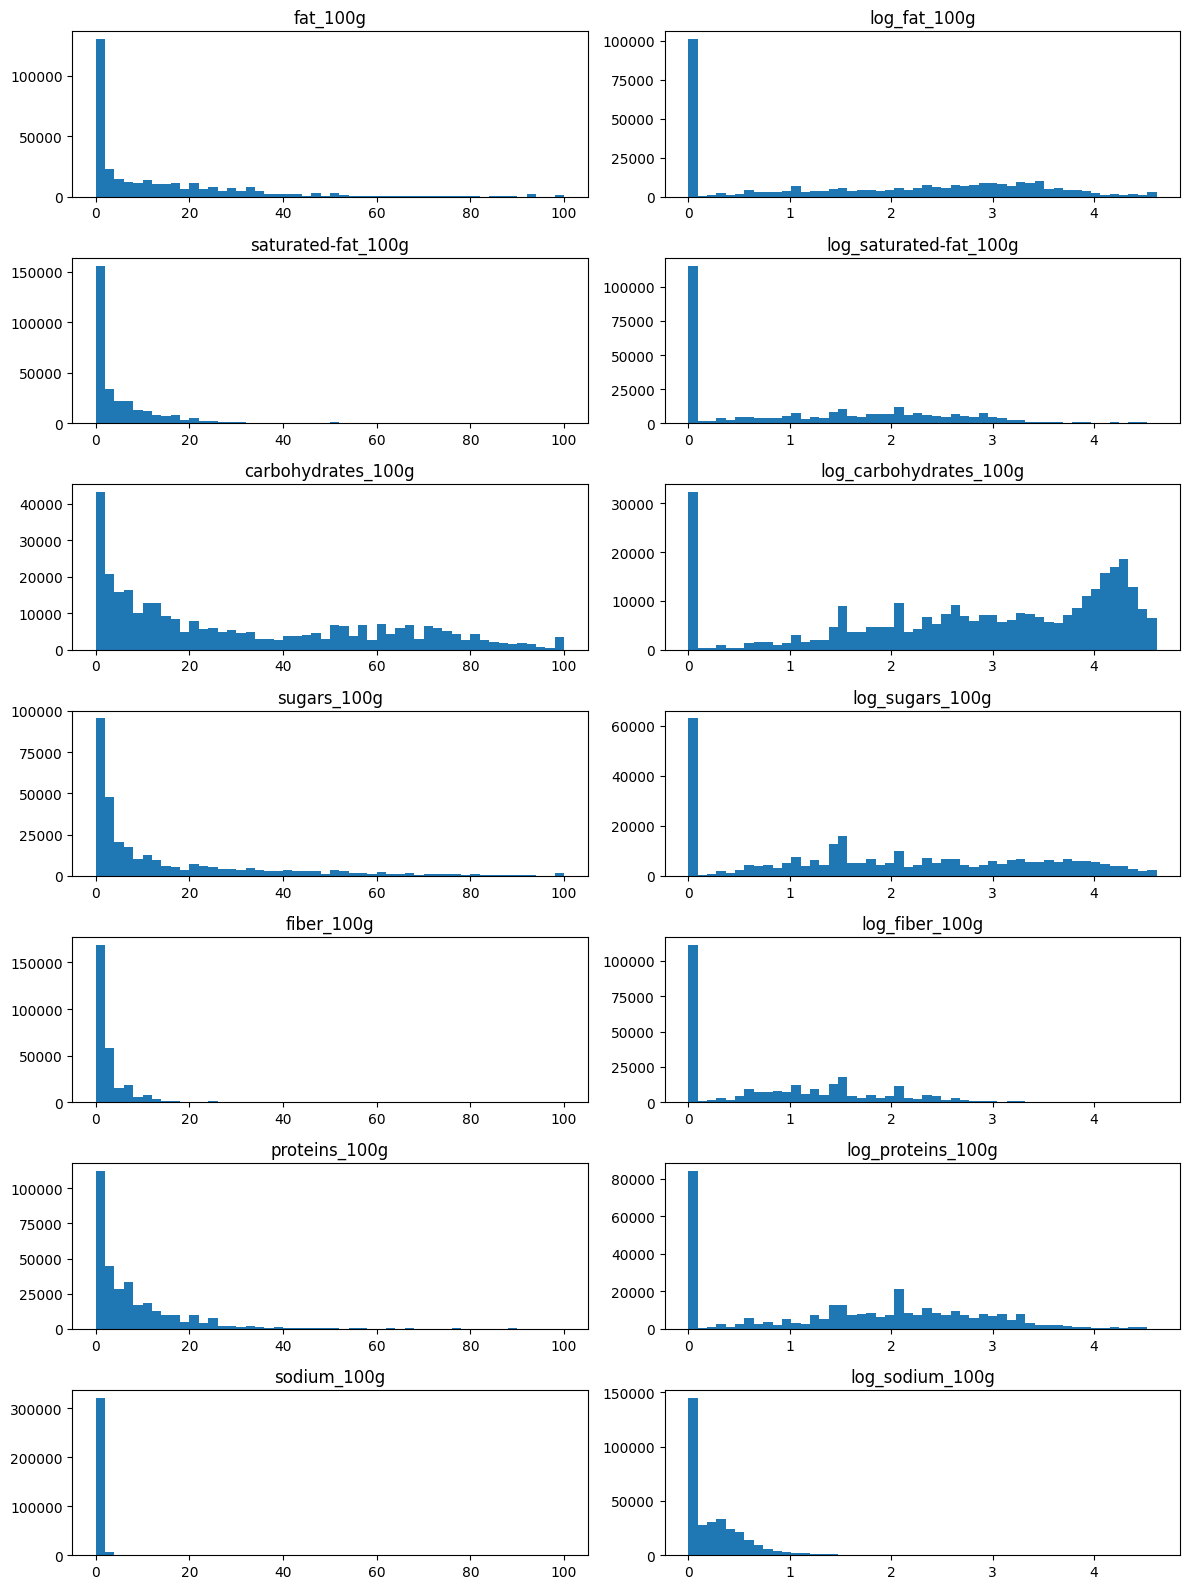

In [61]:
import matplotlib.pyplot as plt
nutrient_cols = ['fat_100g', 'saturated-fat_100g','carbohydrates_100g', 'sugars_100g', 'fiber_100g','proteins_100g', 'sodium_100g']

fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(12,16))
axes = axes.flatten()

for i, col in enumerate(nutrient_cols):                                                                                                               
    axes[i*2].hist(df[col], bins=50)
    axes[i*2].set_title(col) 
    axes[i*2+1].hist(df[f"log_{col}"], bins=50)
    axes[i*2+1].set_title(f"log_{col}")                                                                                                                            
                                          
plt.tight_layout()
plt.show()

After log1p transform, the x-axis compressed significantly and the long tail became more evenly distributed, reducing the influence of extreme values on the model.

I derived calories from macronutrients using the Atwater formula rather than relying on the unreliable energy column in the dataset.

In [62]:
df['calories_100g'] = df['fat_100g']*9 + df['carbohydrates_100g']*4 + df['proteins_100g']*4

Now lets create 2 ratios:
  - protein_calorie_ratio = proteins_100g / calories_100g — how much protein you get per calorie. A high value means the food is protein-dense relative to its caloric load. Think chicken breast vs. a cookie — both might have similar protein grams, but chicken has far fewer calories.
  - fiber_carb_ratio = fiber_100g / carbohydrates_100g — what fraction of the carbohydrates are fiber. High fiber relative to carbs is a marker of a healthy carb source (e.g. beans, vegetables) vs. a low-fiber carb (eg. white bread,sugar).                                                                                                                                                                                                       
                                                                                                                                                                                                                            Why these two specifically:                                                                                                                                                                                                
These are the two ratios most directly tied to the Nutri-Score algorithm itself — Nutri-Score rewards protein and fiber, and penalizes sugar and saturated fat. So these ratios encode the same domain logic the label is based on, which gives the model useful signal.    

In [63]:
df['protein_calorie_ratio'] = df['proteins_100g']/(df['calories_100g'] + 1)
df['fiber_carb_ratio'] = df['fiber_100g']/ (df['carbohydrates_100g'] + 1)

In [64]:
  df[['calories_100g', 'protein_calorie_ratio', 'fiber_carb_ratio']].describe() 

,calories_100g,protein_calorie_ratio,fiber_carb_ratio
count,314500.000000,314500.000000,275560.000000
mean,266.883218,0.031649,0.104368
std,205.823542,0.040022,0.764377
min,0.000000,0.000000,0.000000
25%,76.000000,0.000000,0.000000
50%,253.760000,0.018714,0.042580
75%,403.540000,0.042961,0.114455
max,1700.000000,0.249377,100.000000


Observations:
  1. calories_100g max is 1,700 — reasonable for high-fat foods like oils or nuts. Mean of 267 kcal per 100g makes sense.
  2. protein_calorie_ratio range is 0–0.25 — meaning at most 25% of calories come from protein. Reasonable.
  3. fiber_carb_ratio max is 100 — that's suspicious. A ratio of 100 means fiber is 100x the carbohydrates, which is physically impossible since fiber is a type of carbohydrate.

Note: When carbohydrates_100g is 0 (or missing/zeroed out), the denominator becomes 0 + 1 = 1, so the ratio is just fiber / 1 = fiber. And fiber can legitimately be up to 100g per 100g of food.                 
                                                                                                                                                                                                                             
  So the max of 100 isn't a calculation error — it's a consequence of our +1 fix. The ratio loses its meaning when carbs are zero or missing. 
The fix options are:                                                                                                                                                                
  1. Set fiber_carb_ratio to NaN when carbohydrates_100g is 0 or missing                                                                                                                                                     
  2. Accept it as-is — the model will learn to handle it                                                                                                                                                                     
                                                                                                                                                                                                                             
  For now let's accept it and move on — it affects a small number of rows and the model can handle edge cases.

In [65]:
df['categories'].value_counts().head(10)

categories
undefined                                                     32533
Snacks                                                        29926
Beverages                                                     13542
Snacks, Sweet snacks, Confectioneries                         12400
Condiments, Sauces, Groceries                                 10728
Dairies, Fermented foods, Fermented milk products, Cheeses     9403
Desserts, Frozen foods, Frozen desserts                        8665
Snacks, Sweet snacks, Biscuits and cakes, Biscuits             8632
Toppings & Ingredients                                         6775
Frozen foods                                                   6316
Name: count, dtype: int64

Problems - 
Two things stand out:
                                                                                                                                  
  1. undefined — 32k rows with no category. That's a problem for the recommendation engine which filters by category.
  2. Multi-level categories — values like "Snacks, Sweet snacks, Confectioneries" contain multiple nested categories separated by commas. We only want the top-level category (e.g. "Snacks").

In [66]:
#Lets separate the categories to only take the top
df['category_top'] = df['categories'].str.split(',').str[0]
df['category_top'].head(10)

0      Boissons et préparations de boissons
2                                Sandwiches
3                                      Fats
9                    en:dietary-supplements
28                               Supplement
44                                       膨化
45                           it:integratore
80          Plant-based foods and beverages
117         Plant-based foods and beverages
119                                   Dairy
Name: category_top, dtype: object

a few issues in the sample:                                                                     
                                                                                                                                  
  1. Non-English categories — "Boissons et préparations de boissons" (French), "it:integratore" (Italian), "膨化" (Chinese). This is a global dataset.
  2. Prefixed categories — "en:dietary-supplements" has a language prefix.
  3. Inconsistent naming — "Supplement" and "it:integratore" likely refer to the same thing.
                                                                                                                                                                                                                             
  This is messy real-world data. For our purposes, we don't need to fix all of this — we just need categories to be good enough for the recommendation engine to group similar foods.

In [67]:
#Lets see how many unique values exist
df['category_top'].nunique()

2815

2,815 unique categories is too many to one-hot encode — that would add 2,815 columns to our dataset. Most of them would be rare foreign-language categories with very few rows.                                                                   
                                                                                                                                                                                                                                                     
Lets only the top N most frequent categories and bucket everything else into "Other". 

In [68]:
df['category_top'].value_counts().head(20)

category_top
Snacks                             73490
Plant-based foods and beverages    63076
undefined                          32533
Beverages                          24416
Condiments                         23195
Dairies                            19889
Desserts                           11936
Meats and their products           10640
Meals                              10066
Toppings & Ingredients              6775
Frozen foods                        6639
Seafood                             4970
Sandwiches                          4851
Salted snacks                       4788
Entrees                             3749
Canned foods                        2613
Pizza                               2500
Appetizers & Sides                  2362
Baking decorations                  2194
Sweeteners                          2079
Name: count, dtype: int64

A few observations:
  - undefined is in the top 5 with 32k rows — we'll bucket that into "Other"
  - Top 15 categories cover the vast majority of rows                       
  - Below 20, categories get niche

In [72]:
top_categories = df['category_top'].value_counts().index[:15]
top_categories

Index(['Snacks', 'Plant-based foods and beverages', 'undefined', 'Beverages',
       'Condiments', 'Dairies', 'Desserts', 'Meats and their products',
       'Meals', 'Toppings & Ingredients', 'Frozen foods', 'Seafood',
       'Sandwiches', 'Salted snacks', 'Entrees'],
      dtype='object', name='category_top')

In [73]:
#use np.where(condition, value_if_true, value_if_false)

In [75]:
df['category_top'] = np.where(
    (df['category_top'].isin(top_categories)) & (df['category_top'] != 'undefined'), 
    df['category_top'],
     'Other')

In [76]:
df['category_top'].value_counts()

category_top
Snacks                             73490
Other                              65504
Plant-based foods and beverages    63076
Beverages                          24416
Condiments                         23195
Dairies                            19889
Desserts                           11936
Meats and their products           10640
Meals                              10066
Toppings & Ingredients              6775
Frozen foods                        6639
Seafood                             4970
Sandwiches                          4851
Salted snacks                       4788
Entrees                             3749
Name: count, dtype: int64

Great, lets encode these now, since these are categories and models can't work with strings. We could do-
1. Label encoding -  assign each category an integer (Snacks=0, Beverages=1, etc.) 
2. One hot encoding - create a binary column for each category (is_Snacks, is_Beverages, etc.) 
I am using one-hot encoding for food categories because they are nominal — there's no meaningful order between Snacks and Beverages. Label encoding would 
introduce false ordinality that could mislead the model


In [78]:
df = pd.concat([df, pd.get_dummies(df['category_top'], prefix='cat')], axis = 1)
df.shape

(333984, 39)

In [79]:
df.to_csv("../data/processed/features_labeled.csv", index=False) 

## What I learned
1. we used log1p because we wanted to map 0 to 0, since nutrient columns had legitimate 0s. 
2. We used one hot because we did not want to introduce any ordering or weights, because all categories have same level 
3. we did not use energy-kcal_100g because this column was unreliable, it appeared to be in kJ not kcal, also this can easily be derived so we avoided redundancy in features   